In [1]:
import numpy as np
import healpy as hp
#from rubin_scheduler.scheduler.utils import make_rolling_footprints
DEFAULT_NSIDE = 32
from rubin_scheduler.scheduler.utils import Footprint, Footprints, CurrentAreaMap, StepSlopes, slice_quad_galactic_cut
import copy

from rubin_scheduler.scheduler.utils import CurrentAreaMap, Footprint
from rubin_scheduler.scheduler.model_observatory import ModelObservatory

import healpy as hp
%matplotlib inline
import numpy as np

import rubin_scheduler.scheduler.basis_functions as bf
from rubin_scheduler.scheduler.surveys import BlobSurvey
from rubin_scheduler.scheduler.schedulers import CoreScheduler, BaseQueueManager
from rubin_scheduler.scheduler import sim_runner
from rubin_scheduler.utils import DEFAULT_NSIDE, ra_dec2_hpid

from rubin_scheduler.scheduler.basis_functions import BaseBasisFunction
from rubin_scheduler.scheduler.detailers import BaseDetailer
from rubin_scheduler.site_models import Almanac


import matplotlib.pylab as plt
from astropy.time import Time

SURVEY_START_MJD = Time("2026-04-01T12:00:00").mjd


In [2]:
def make_rolling_footprints(
    fp_hp=None,
    mjd_start=60218.0,
    sun_ra_start=3.27717639,
    nslice=2,
    scale=0.8,
    nside=DEFAULT_NSIDE,
    wfd_indx=None,
    order_roll=0,
    n_cycles=None,
    n_constant_start=2,
    n_constant_end=6,
    verbose=False,
    uniform=True,
    kludge=True,
):
    """
    Generate rolling footprints

    Parameters
    ----------
    fp_hp : dict-like
        A dict with band name keys and HEALpix map values.
        Default None will load CurrentAreaMap. Assumes
        WFD is where r-band is 1.
    mjd_start : `float`
        The starting date of the survey.
    sun_ra_start : `float`
        The RA of the sun at the start of the survey
    nslice : `int`
        How much to slice the sky up. Can be 2, 3, 4, or 6.
    scale : `float`
        The strength of the rolling, value of 1 is full power rolling.
        Zero is no rolling.
    wfd_indx : array of ints
        The indices of the HEALpix map that are to be included in the rolling.
    order_roll : `int`
        Change the order of when bands roll. Default 0.
    n_cycles : `int`
        Number of complete rolling cycles to attempt. If None, defaults to 3
        full cycles for nslice=2, 2 cycles for nslice=3 or 4, and 1 cycle for
        nslice=6.
    n_constant_start : `int`
        The number of constant non-rolling seasons to start with. Anything
        less than 2 will start rolling too early near Y1. Defaults to 2.
    n_constant_end : `int`
        The number of constant seasons to end the survey with. Defaults to 6.
    kludge : `bool`
        Horrible kludge to mix and match behavior so constant season 
        added to the start and first constant season after rolling
        is removed.

    Returns
    -------
    Footprints object
    """

    if fp_hp is None:
        sky = CurrentAreaMap(nside=nside)
        footprints, labels = sky.return_maps()
        fp_hp = {}
        for key in footprints.dtype.names:
            fp_hp[key] = footprints[key]

    nc_default = {2: 3, 3: 2, 4: 2, 6: 1}
    if n_cycles is None:
        n_cycles = nc_default[nslice]

    hp_footprints = fp_hp

    D = 1.0 - scale
    U = nslice - D * (nslice - 1)

    start = [1.0] * n_constant_start
    # After n_cycles, just go to no-rolling for 6 years.
    end = [1.0] * n_constant_end

    rolling = [U] + [D] * (nslice - 1)
    rolling = np.roll(rolling, order_roll).tolist()

    all_slopes = []
    if uniform:
        extra_constant = [1]
    else:
        extra_constant = []

    for i in range(nslice):
        _roll = np.roll(rolling, i).tolist() + extra_constant
        all_slopes.append(start + _roll * n_cycles + end)
    for i in range(nslice):
        _roll = np.roll(rolling, i).tolist() + extra_constant
        _roll = [_roll[-1]] + _roll[1:-1] + [_roll[0]]
        all_slopes.append(start + _roll * n_cycles + end)
    
    if verbose:
        dvals = {
        1: "1",
        D: "D",
        U: "U",
    }
        abc = ["a", "b", "c", "d", "e", "f", "g", "h"]
        slice_names = ["slice %s" % abc[i] for i in range(nslice)]
        for i, s in enumerate(all_slopes):
            if i >= nslice:
                sname = slice_names[i - nslice] + " w/ ra - sun_ra in [90, 270]"
            else:
                sname = slice_names[i] + " w/ ra - sun_ra in [270, 90]"
            
            print(sname + ": " + " ".join([dvals[x] for x in s]))

    fp_non_wfd = Footprint(mjd_start, sun_ra_start=sun_ra_start, nside=nside)
    rolling_footprints = []
    

    # Insert a constant season at the start, remove the first constant season after rolling
    if kludge:
        new_all_slopes = []
        for slopes in all_slopes:
            new_slopes = copy.copy(slopes)
            new_slopes = [1.0] + new_slopes
            # which constant to remove?
            indx = np.where((np.diff(new_slopes) != 0) & (np.array(new_slopes)[1:] == 1))[0].min()
            del new_slopes[indx + 1]
            new_all_slopes.append(new_slopes)
        all_slopes = new_all_slopes

    for i in range(len(all_slopes)):
        step_func = StepSlopes(rise=all_slopes[i])
        rolling_footprints.append(
            Footprint(
                mjd_start,
                sun_ra_start=sun_ra_start,
                step_func=step_func,
                nside=nside,
            )
        )

    wfd = hp_footprints["r"] * 0
    if wfd_indx is None:
        wfd_indx = np.where(hp_footprints["r"] == 1)[0]

    wfd[wfd_indx] = 1
    non_wfd_indx = np.where(wfd == 0)[0]

    if uniform:
        split_wfd_indices = slice_quad_galactic_cut(
            hp_footprints,
            nslice=nslice,
            wfd_indx=wfd_indx,
            ra_range=(sun_ra_start + 1.5 * np.pi, sun_ra_start + np.pi / 2),
        )

        split_wfd_indices_delayed = slice_quad_galactic_cut(
            hp_footprints,
            nslice=nslice,
            wfd_indx=wfd_indx,
            ra_range=(sun_ra_start + np.pi / 2, sun_ra_start + 1.5 * np.pi),
        )
    else:
        split_wfd_indices = slice_quad_galactic_cut(hp_footprints, nslice=nslice, wfd_indx=wfd_indx)

    for key in hp_footprints:
        temp = hp_footprints[key] + 0
        temp[wfd_indx] = 0
        fp_non_wfd.set_footprint(key, temp)

        for i in range(nslice):
            # make a copy of the current band
            temp = hp_footprints[key] + 0
            # Set the non-rolling area to zero
            temp[non_wfd_indx] = 0

            indx = split_wfd_indices[i]
            # invert the indices
            ze = temp * 0
            ze[indx] = 1
            temp = temp * ze
            rolling_footprints[i].set_footprint(key, temp)
        if uniform:
            for _i in range(nslice, nslice * 2):
                # make a copy of the current band
                temp = hp_footprints[key] + 0
                # Set the non-rolling area to zero
                temp[non_wfd_indx] = 0

                indx = split_wfd_indices_delayed[_i - nslice]
                # invert the indices
                ze = temp * 0
                ze[indx] = 1
                temp = temp * ze
                rolling_footprints[_i].set_footprint(key, temp)

    result = Footprints([fp_non_wfd] + rolling_footprints)
    return result


In [3]:
ack = make_rolling_footprints()

In [4]:
# Parameters for rolling cadence footprint definition
nslice = 2  # N slices for rolling
rolling_scale = 0.9  # Strength of rolling
rolling_uniform = True  # Should we use the uniform rolling flag

nside = 32
sky = CurrentAreaMap(nside=nside)
footprints_hp_array, labels = sky.return_maps()
# Identify pixels for rolling
roll_indx = np.where((labels == "lowdust") | (labels == "virgo"))[0]
roll_footprint = footprints_hp_array["r"] * 0
roll_footprint[roll_indx] = 1

footprints_hp = {}
for key in footprints_hp_array.dtype.names:
    footprints_hp[key] = footprints_hp_array[key]

# Set up a mask to contain some surveys within this region
footprint_mask = footprints_hp["r"] * 0
footprint_mask[np.where(footprints_hp["r"] > 0)] = 1

# Use the Almanac to find the position of the sun at the start of survey
almanac = Almanac(mjd_start=SURVEY_START_MJD)
sun_moon_info = almanac.get_sun_moon_positions(SURVEY_START_MJD)
sun_ra_start = sun_moon_info["sun_RA"].copy()

# Define the rolling footprint
fp = make_rolling_footprints(
    fp_hp=footprints_hp,
    mjd_start=SURVEY_START_MJD,
    sun_ra_start=sun_ra_start,
    nslice=nslice,
    scale=rolling_scale,
    nside=nside,
    wfd_indx=roll_indx,
    order_roll=1,
    n_cycles=3,
    uniform=rolling_uniform,
)

/Users/yoachim/anaconda3/envs/rubin_14/lib/python3.14/site-packages/healpy/visufunc.py:223: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  f = pylab.figure(fig, figsize=(8.5, 5.4))


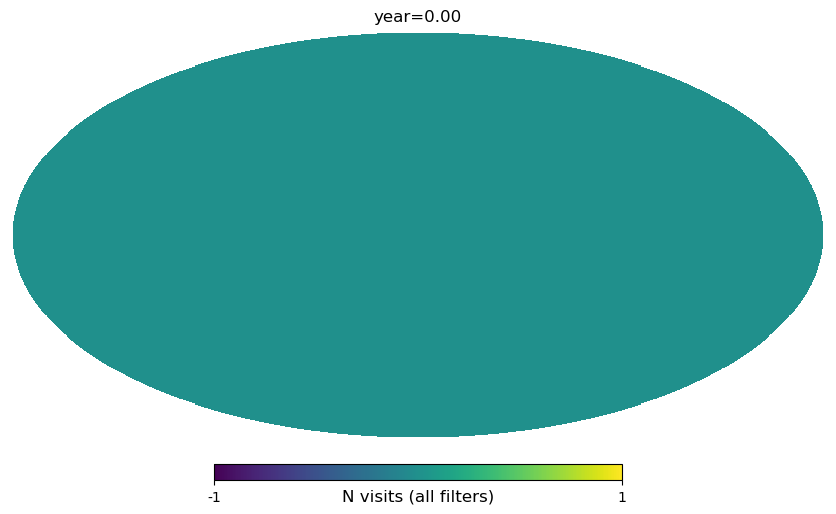

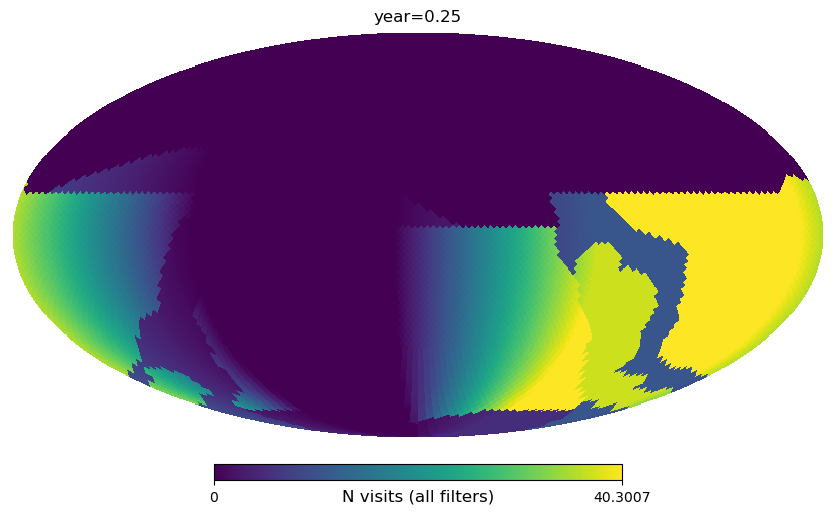

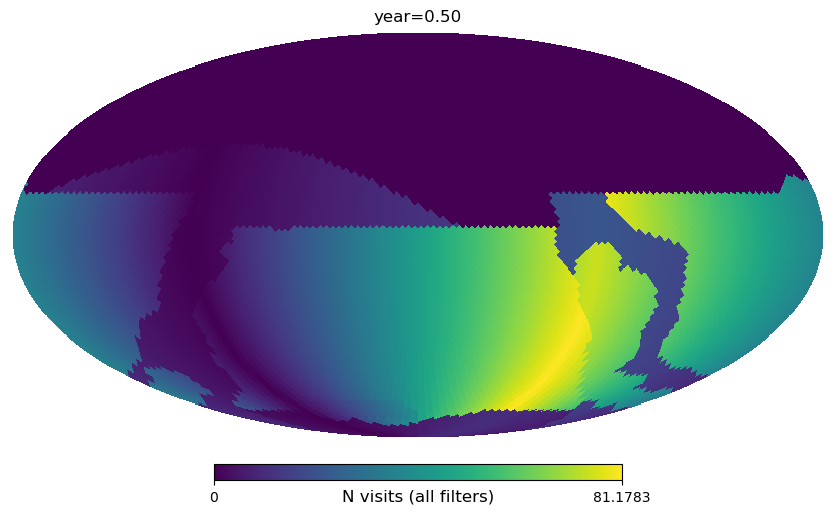

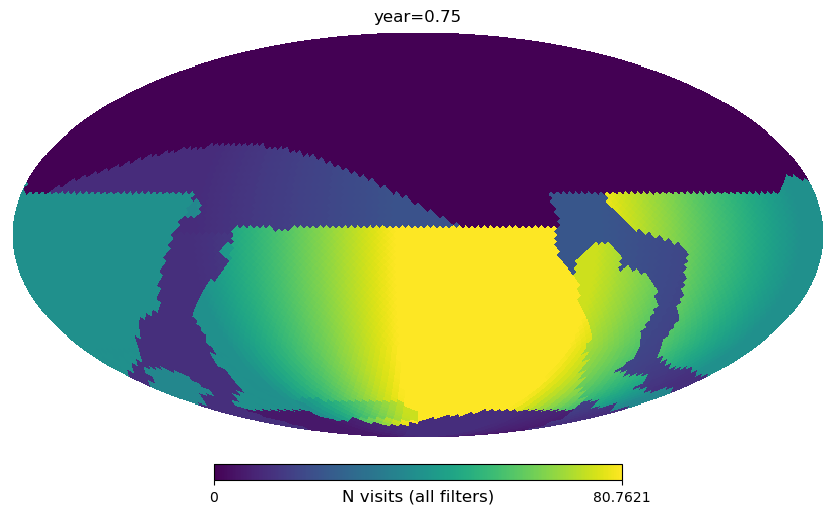

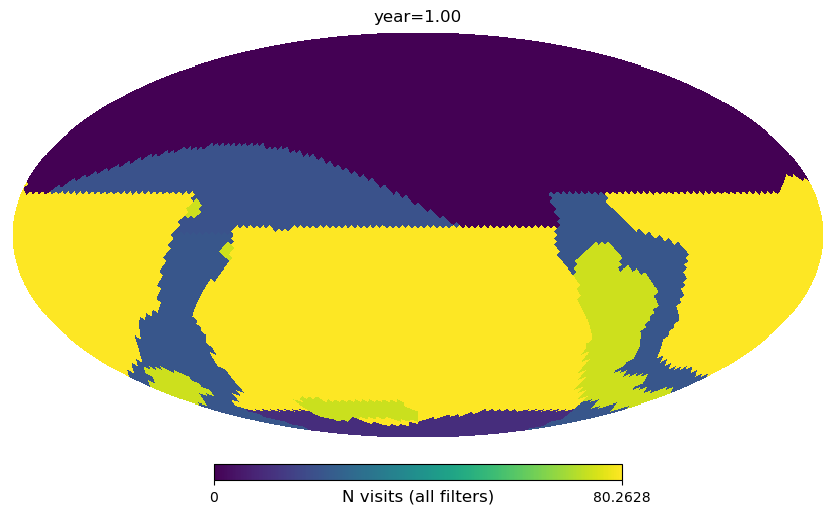

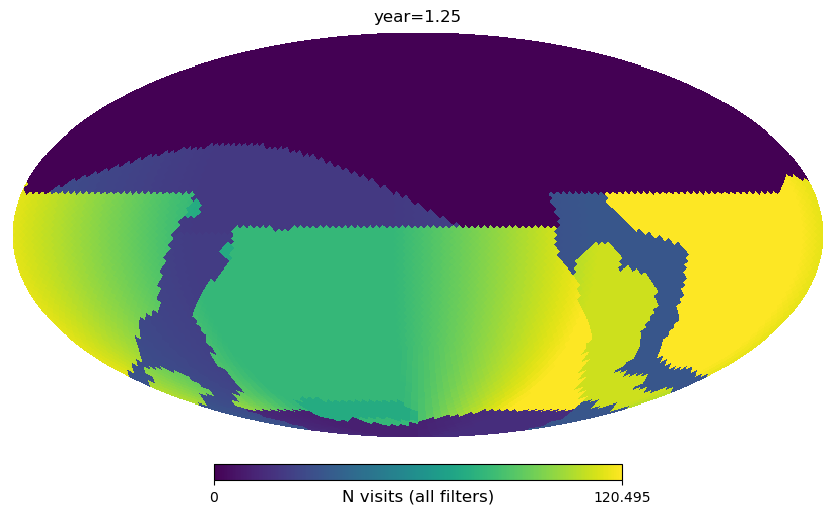

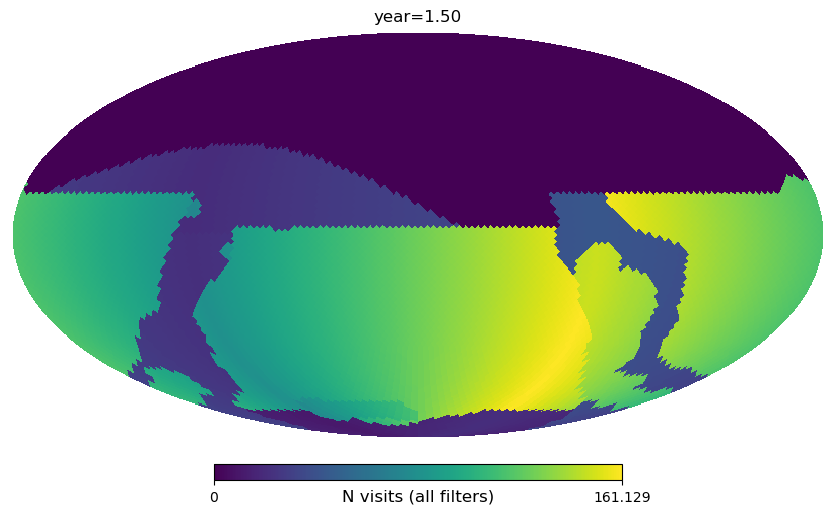

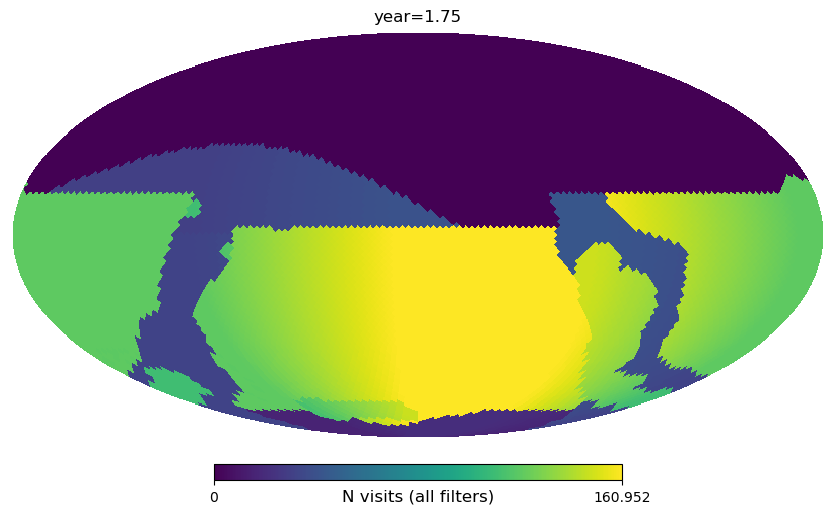

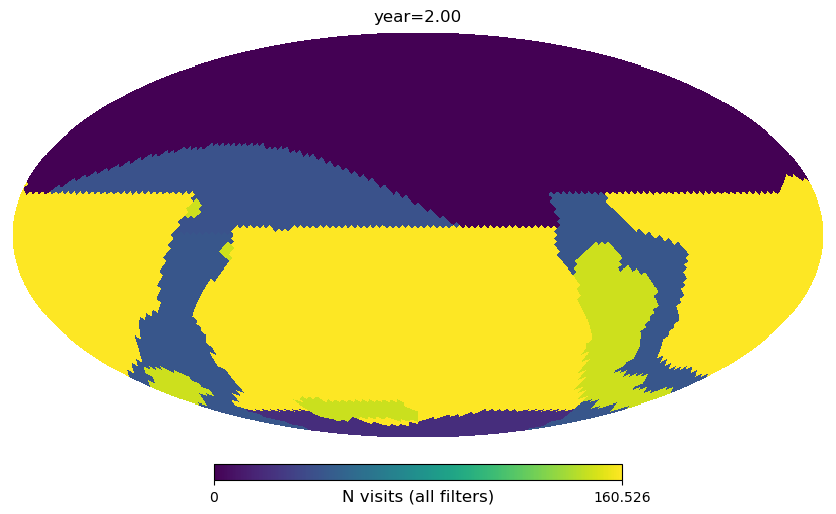

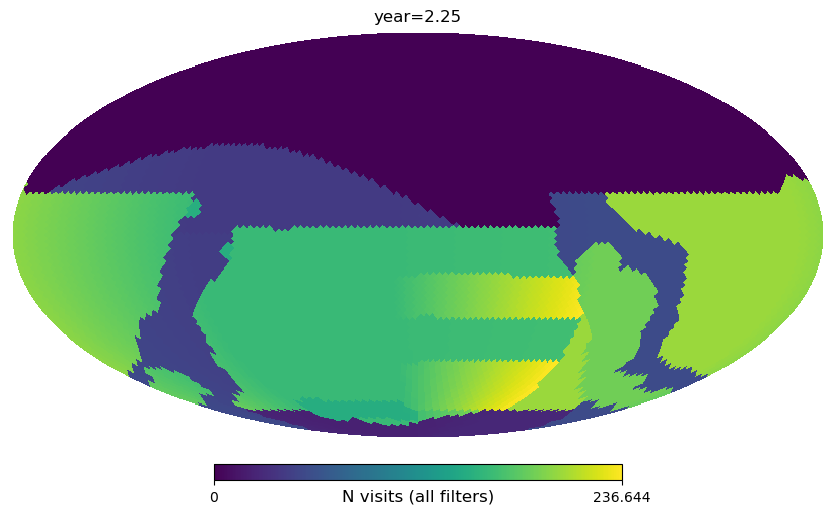

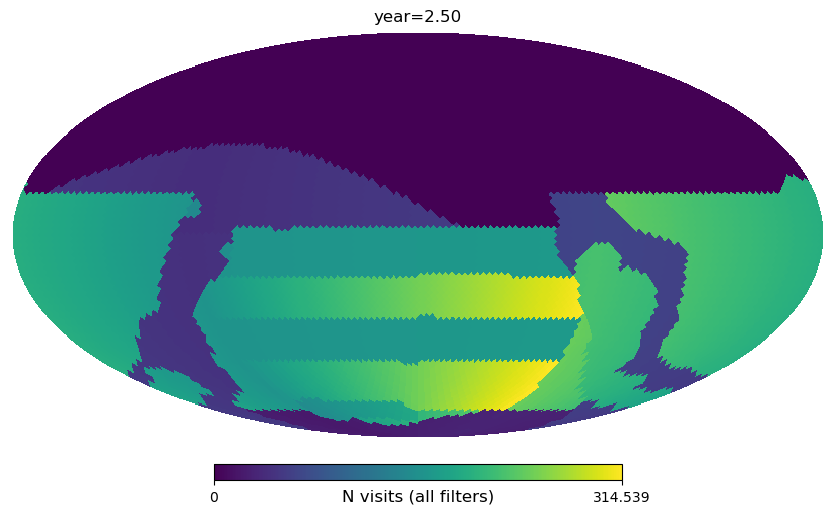

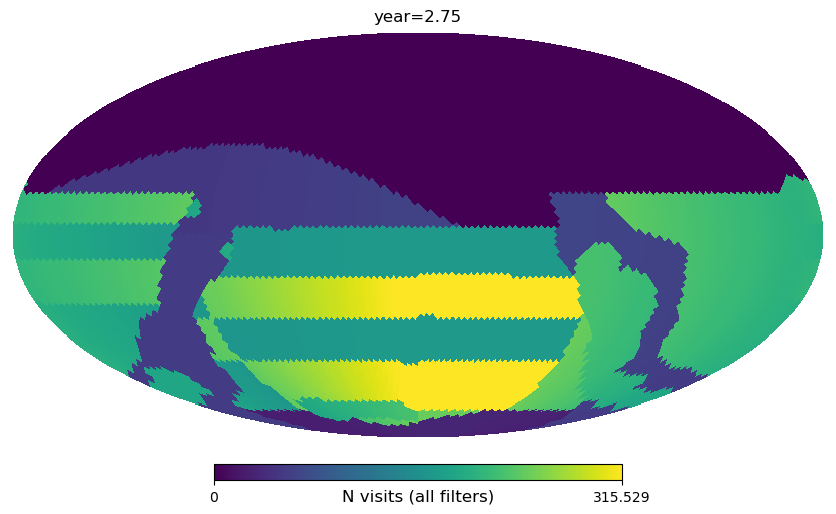

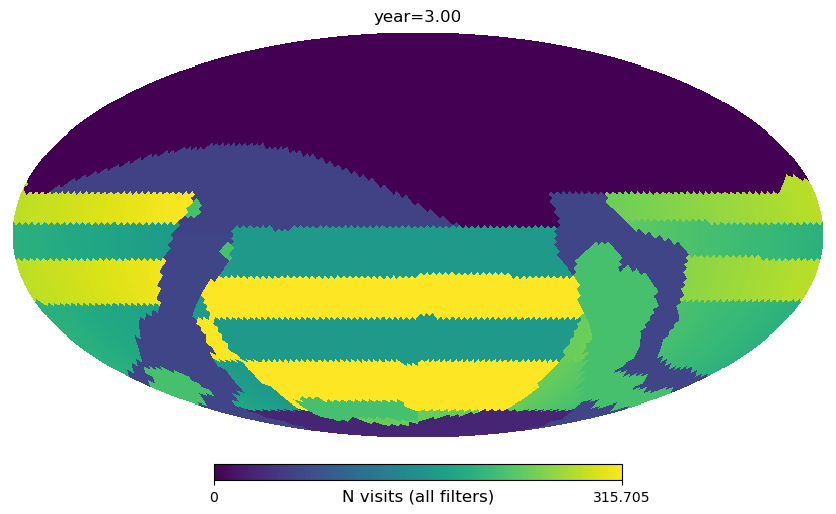

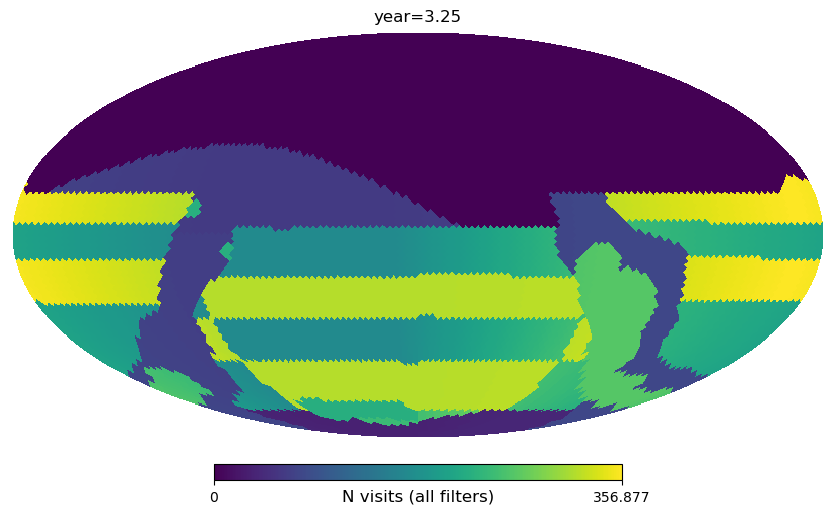

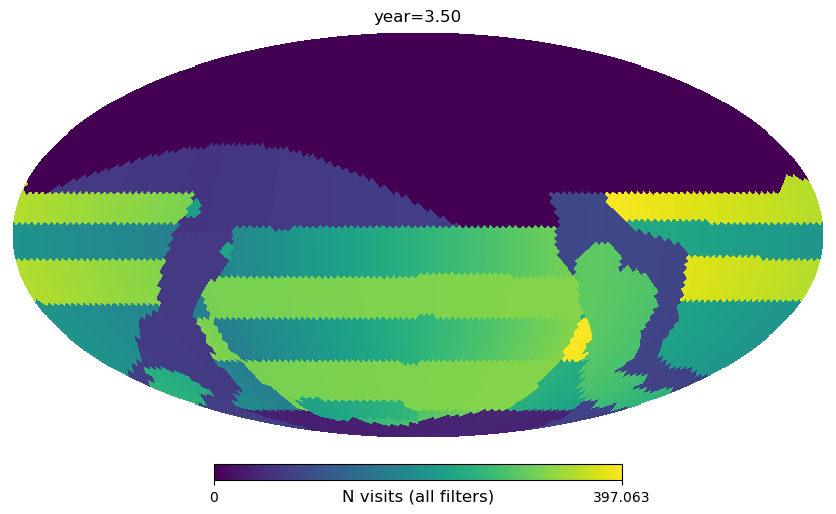

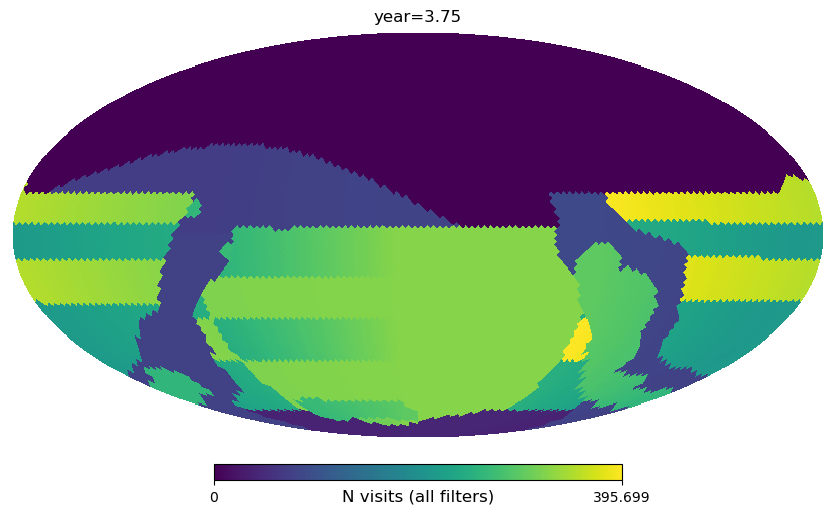

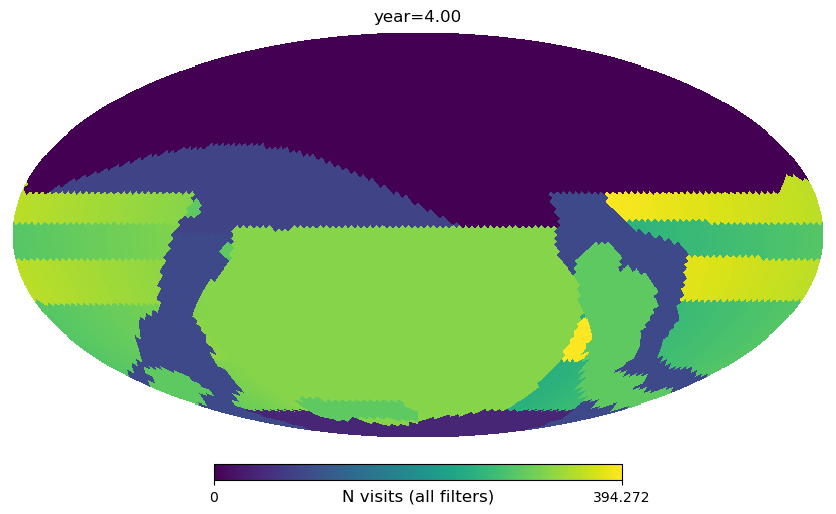

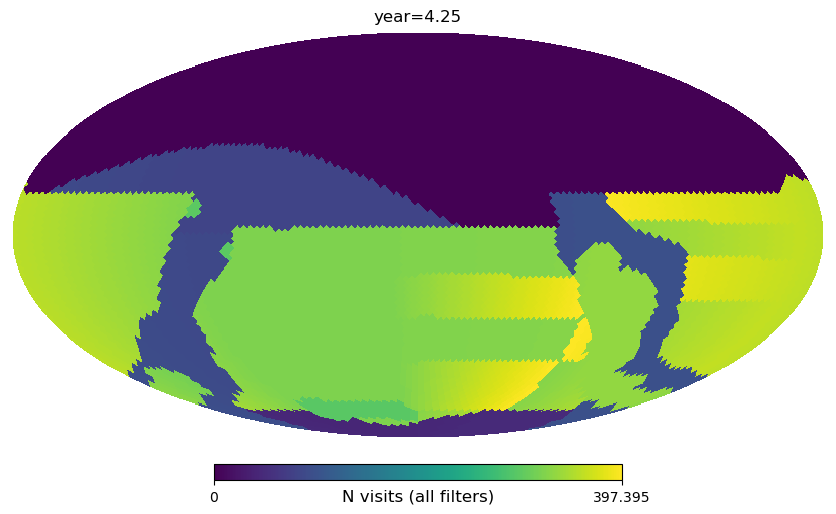

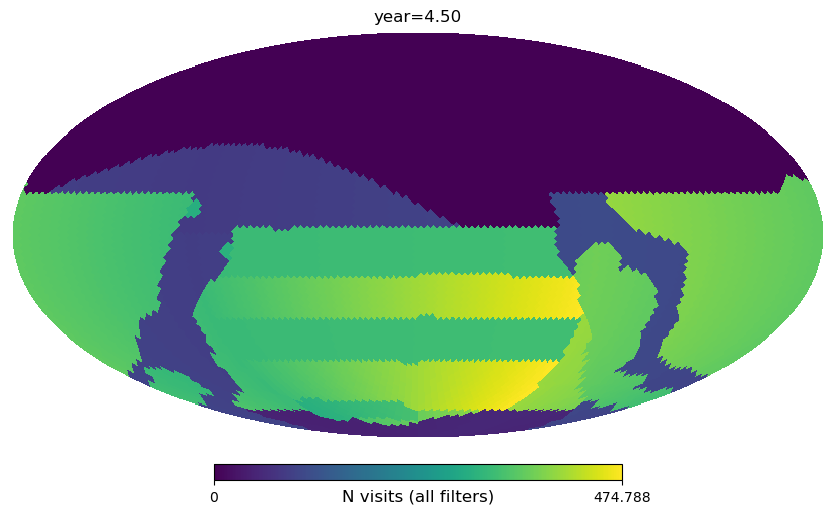

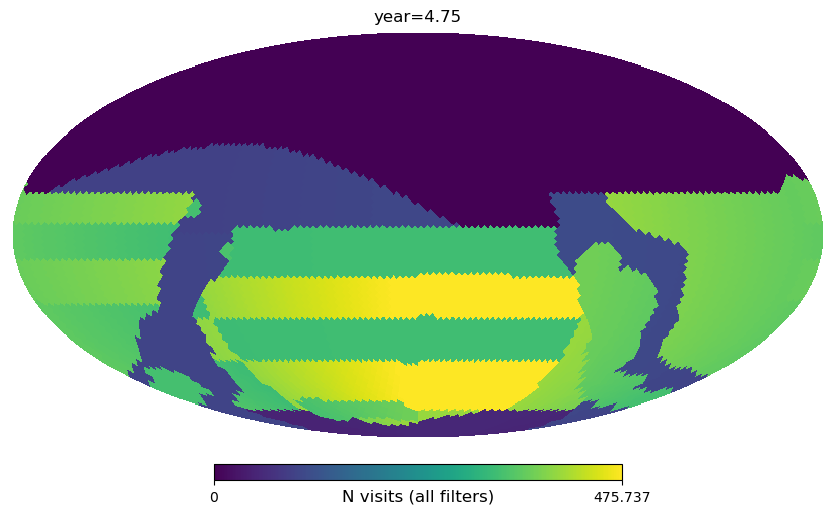

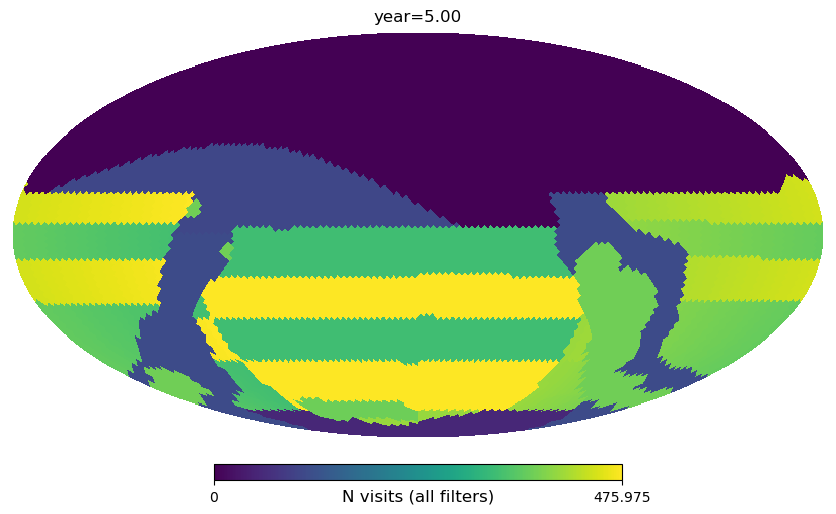

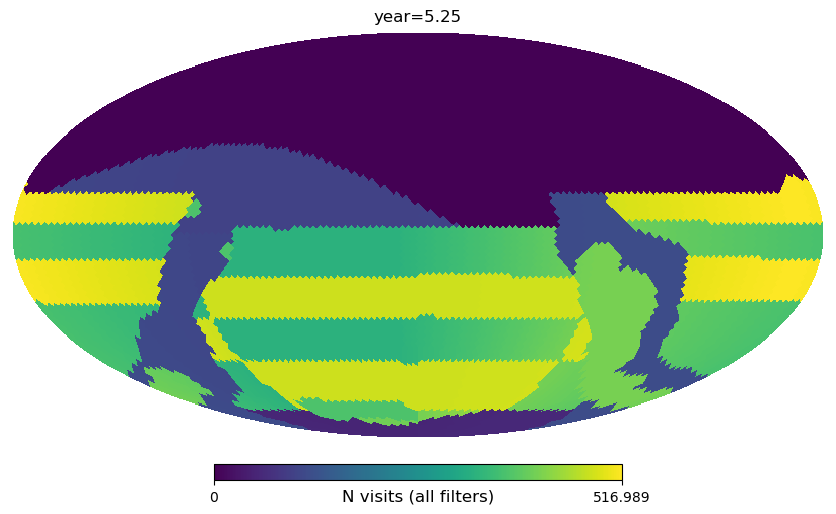

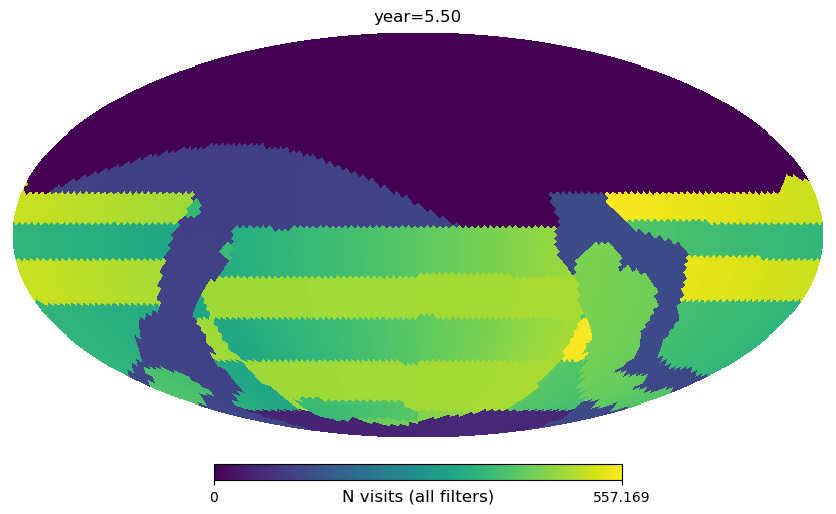

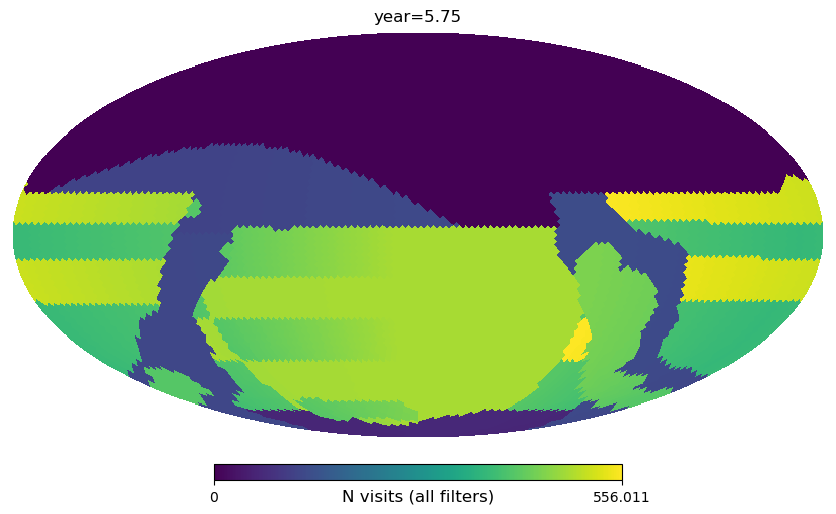

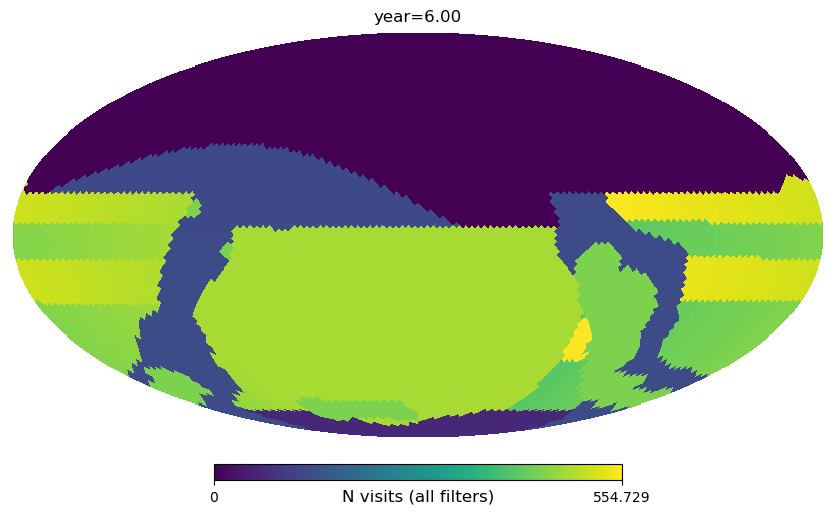

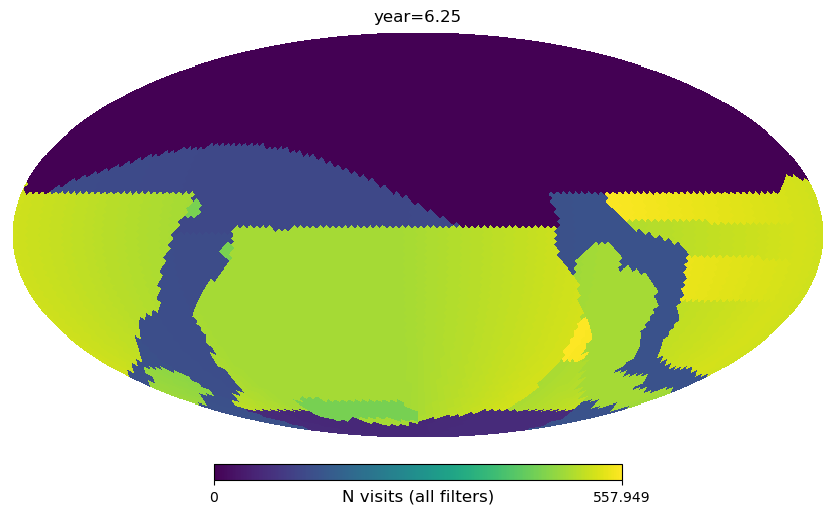

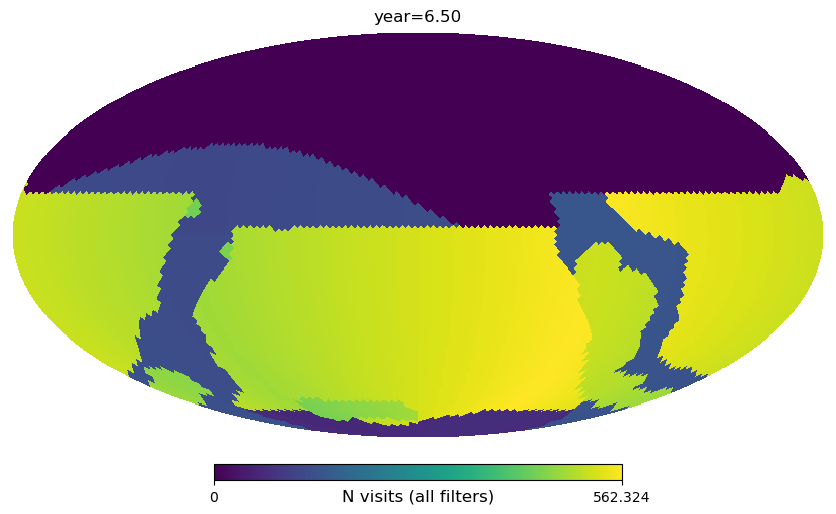

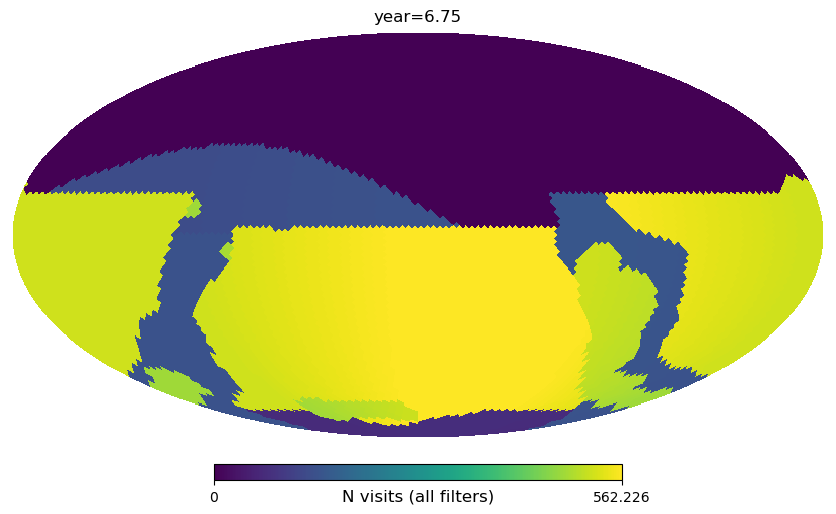

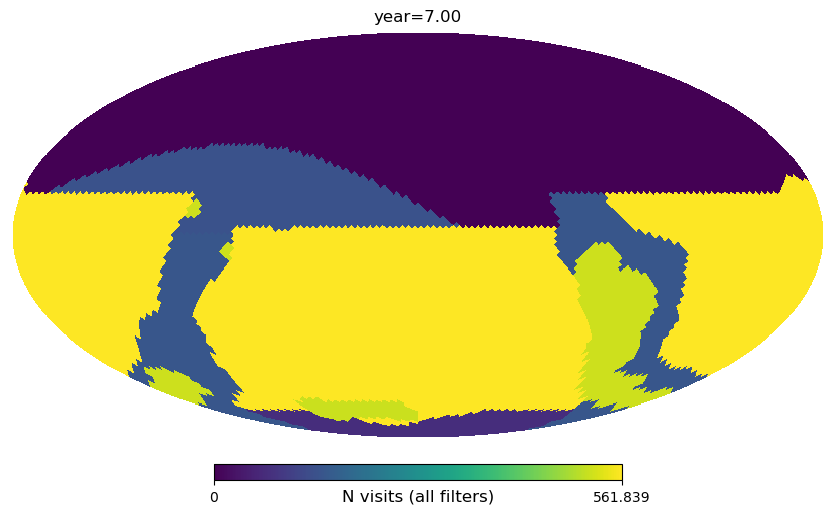

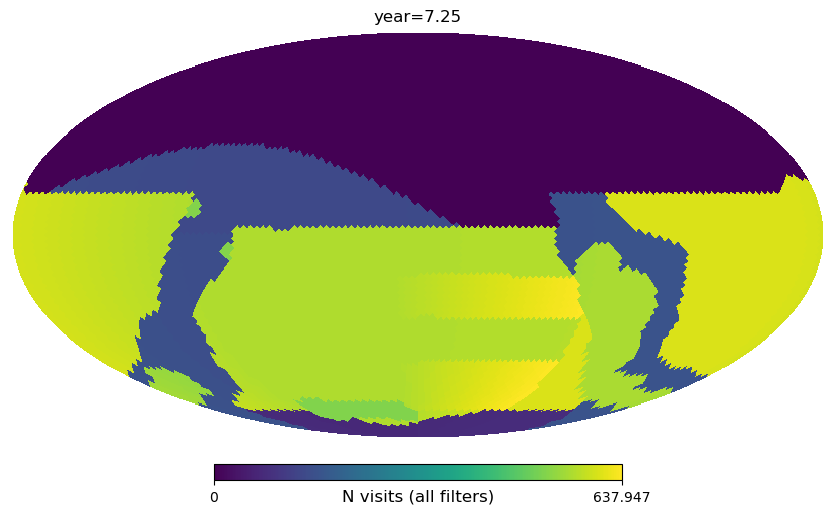

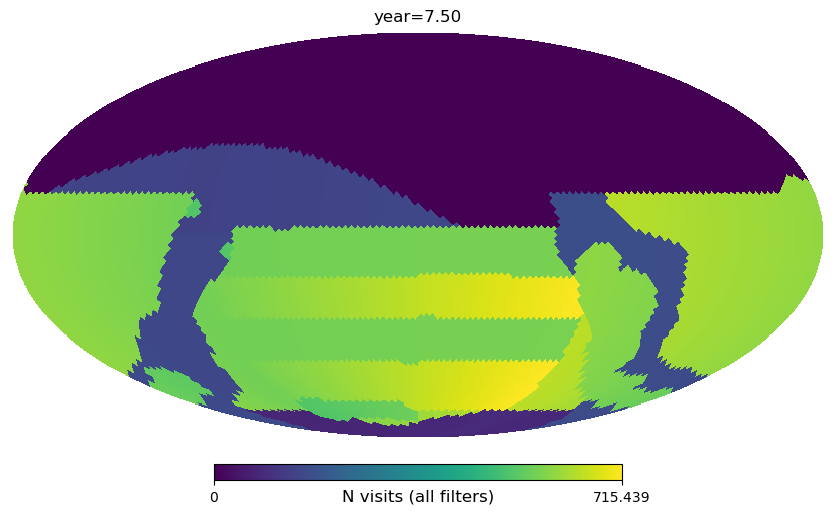

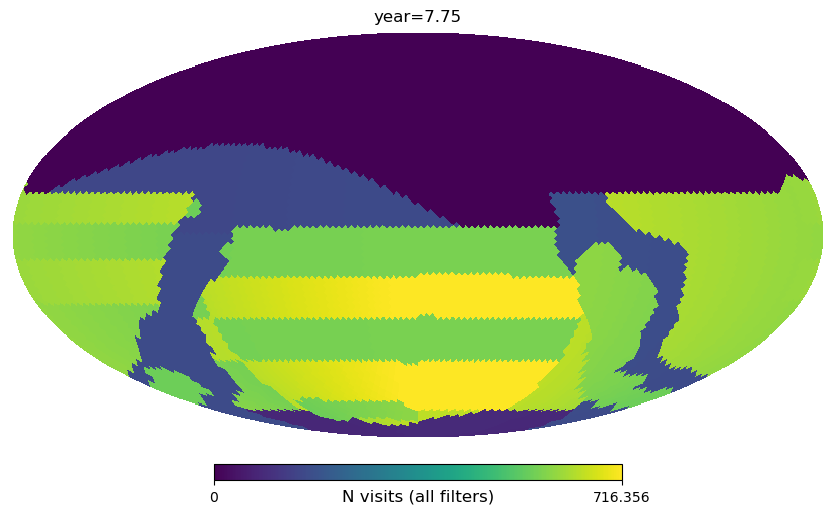

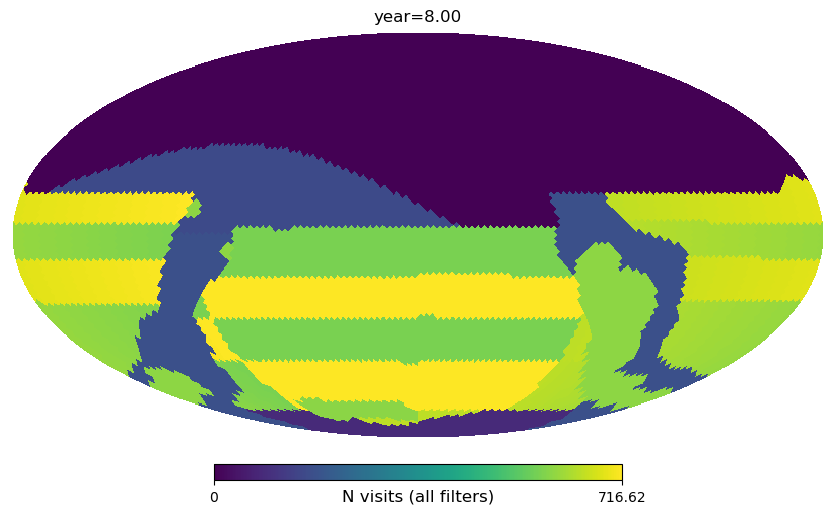

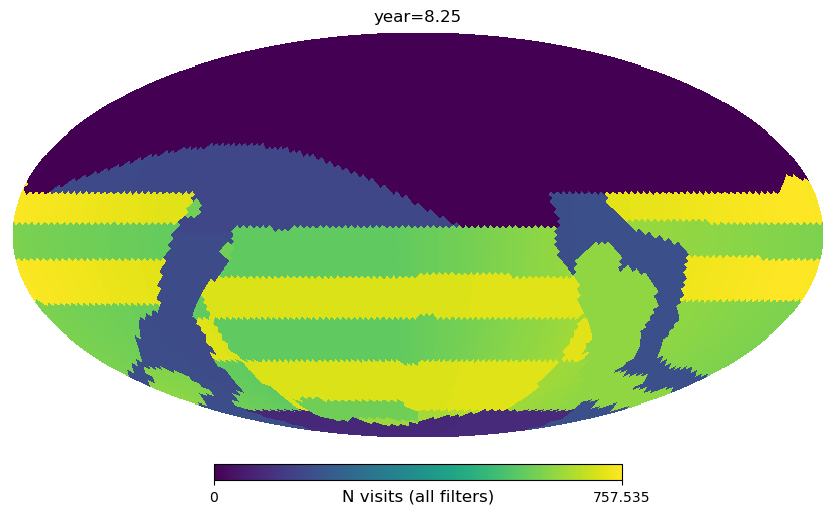

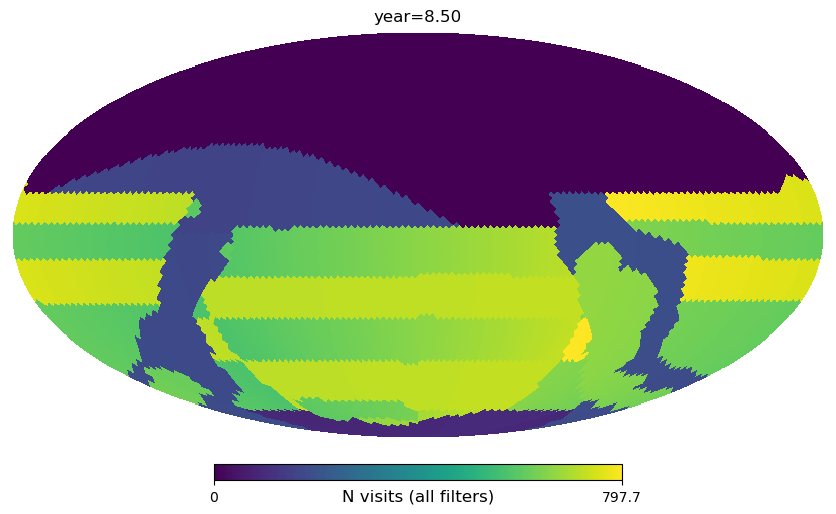

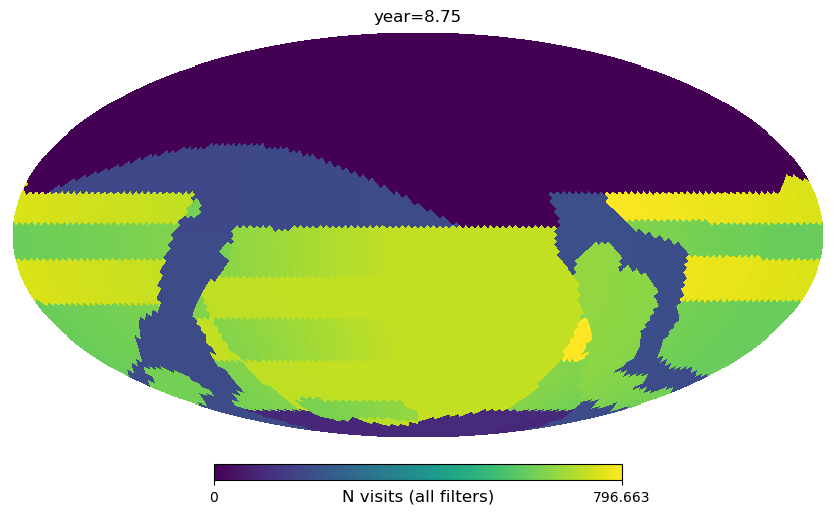

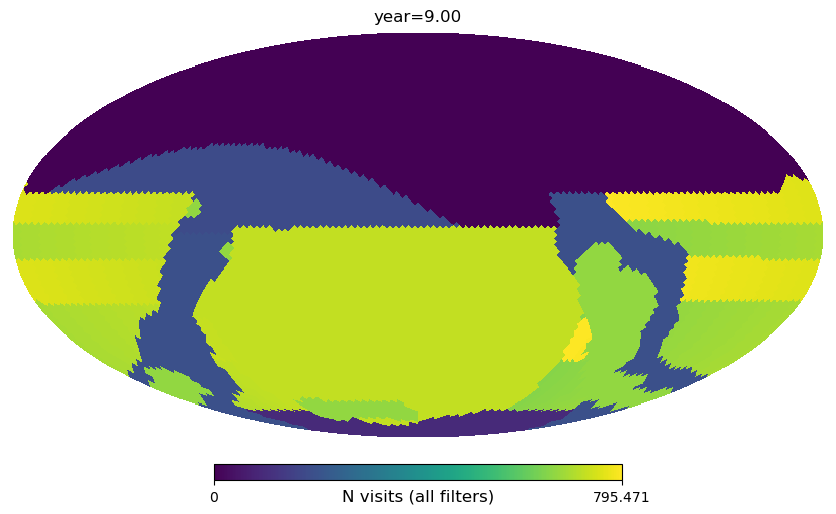

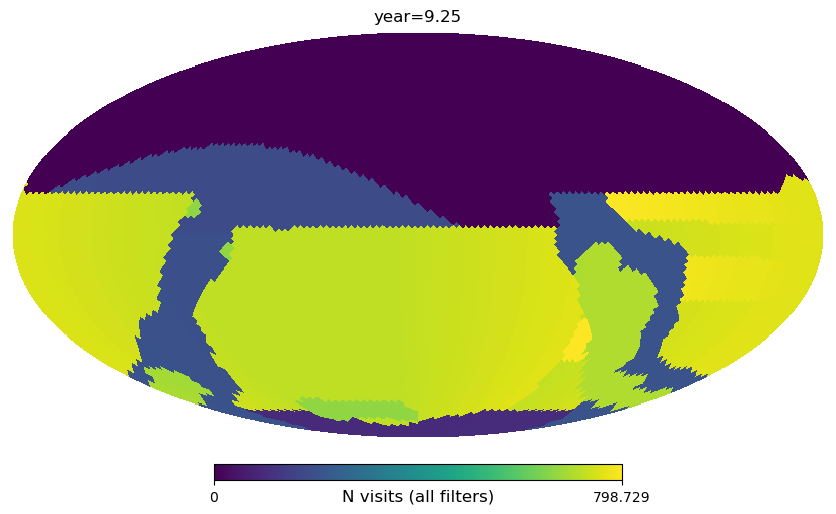

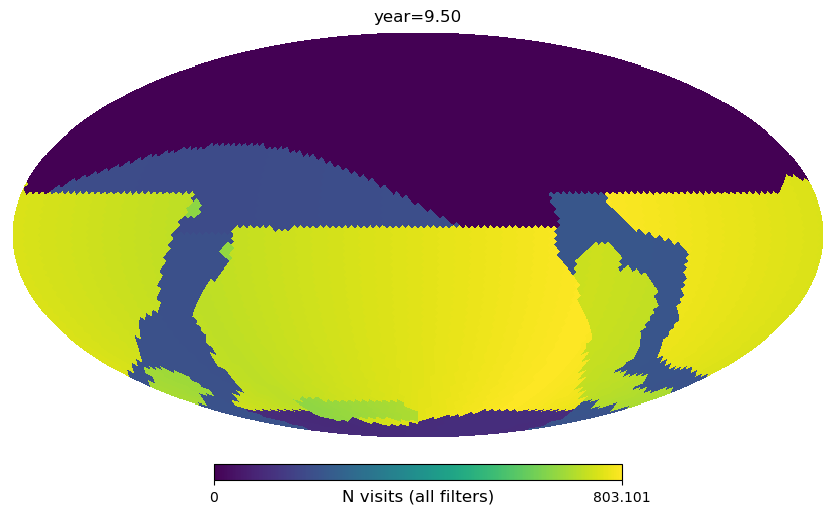

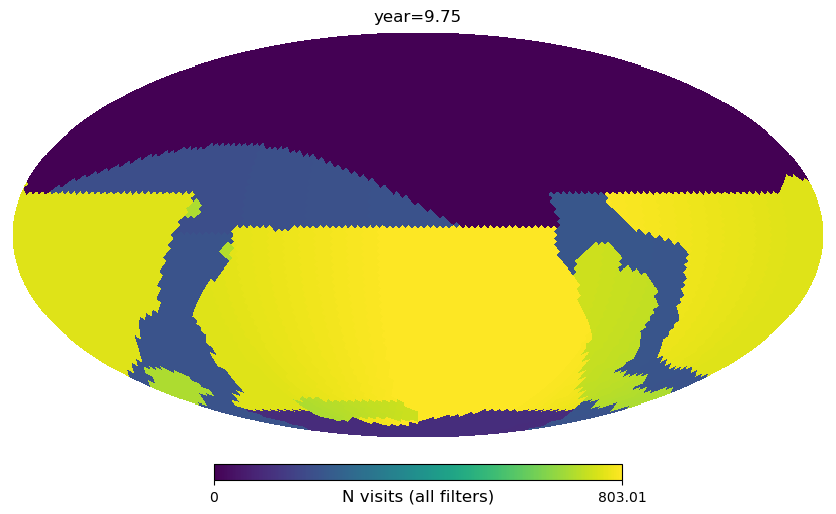

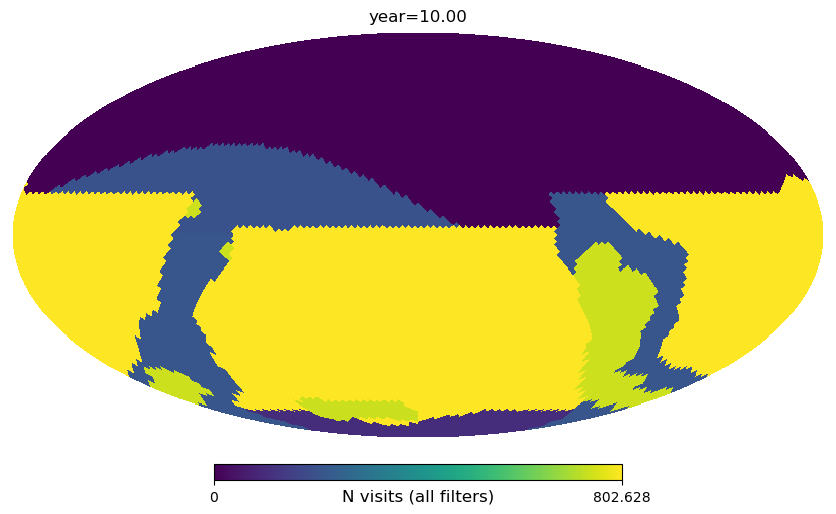

In [5]:
mjd = SURVEY_START_MJD + 10
step =  365.25/4
for mjd in SURVEY_START_MJD + np.arange(0,3652+step, step):
    # Assume we gather visits linearly. 
    fp_at_mjd = fp.estimate_counts(mjd, nvisits=1.8e6/3652*(mjd-SURVEY_START_MJD))
    sums = 0
    for key in fp_at_mjd.dtype.names:
        sums += fp_at_mjd[key]
    hp.mollview(sums, title='year=%.2f' % ((mjd-SURVEY_START_MJD)/365.25), unit="N visits (all filters)")
